In [1]:
import torch
import cv2
import timm
import numpy as np

print("=" * 40)
print("🔍 ENVIRONMENT CHECK")
print("=" * 40)
print(f"✅ PyTorch  : {torch.__version__}")
print(f"✅ CUDA     : {torch.cuda.is_available()}")
print(f"✅ GPU      : {torch.cuda.get_device_name(0)}")
print(f"✅ VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"✅ OpenCV   : {cv2.__version__}")
print("=" * 40)
print("🚀 RTX 4070 Ready!")
print("=" * 40)

🔍 ENVIRONMENT CHECK
✅ PyTorch  : 2.6.0+cu124
✅ CUDA     : True
✅ GPU      : NVIDIA GeForce RTX 4070 Ti SUPER
✅ VRAM     : 16.0 GB
✅ OpenCV   : 4.13.0
🚀 RTX 4070 Ready!


In [3]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import shutil

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [3]:
# Create all required folders
BASE_DIR = "E:/document_forensics"

folders = [
    "dataset/sharp",
    "dataset/blur",
    "dataset/train/sharp",
    "dataset/train/blur",
    "dataset/val/sharp",
    "dataset/val/blur",
    "dataset/test/sharp",
    "dataset/test/blur",
    "models",
    "results"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("✅ Folder structure created!")
print("\n📁 Structure:")
for folder in folders:
    print(f"   E:/document_forensics/{folder}")

✅ Folder structure created!

📁 Structure:
   E:/document_forensics/dataset/sharp
   E:/document_forensics/dataset/blur
   E:/document_forensics/dataset/train/sharp
   E:/document_forensics/dataset/train/blur
   E:/document_forensics/dataset/val/sharp
   E:/document_forensics/dataset/val/blur
   E:/document_forensics/dataset/test/sharp
   E:/document_forensics/dataset/test/blur
   E:/document_forensics/models
   E:/document_forensics/results


In [7]:
import random
import shutil
from tqdm import tqdm

RVL_CDIP_ROOT = "E:/RVL-CDIP"
LABEL_FILE    = os.path.join(RVL_CDIP_ROOT, "labels/train.txt")
IMAGE_ROOT    = os.path.join(RVL_CDIP_ROOT, "image_jpg")
SHARP_DIR     = "E:/document_forensics/dataset/sharp"

# Read label file
entries = []
with open(LABEL_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.split()
            entries.append(parts[0])

print(f"📋 Total images in dataset: {len(entries)}")

# Shuffle and pick 5000
random.shuffle(entries)
selected = entries[:5000]

# Copy images
copied = 0
failed = 0

for i, rel_path in enumerate(tqdm(selected, desc="Copying sharp images")):
    base = os.path.splitext(rel_path)[0]
    
    for ext in ['.jpg', '.jpeg', '.tif', '.tiff', '.png']:
        full_path = os.path.join(IMAGE_ROOT, base + ext)
        if os.path.exists(full_path):
            dest = os.path.join(SHARP_DIR, f"sharp_{copied:05d}{ext}")
            shutil.copy2(full_path, dest)
            copied += 1
            break
    else:
        failed += 1

print(f"\n✅ Copied  : {copied} sharp images")
print(f"⚠️ Failed  : {failed} images not found")
print(f"📁 Saved to: {SHARP_DIR}")

📋 Total images in dataset: 320000


Copying sharp images: 100%|██████████| 5000/5000 [00:06<00:00, 725.33it/s]


✅ Copied  : 5000 sharp images
⚠️ Failed  : 0 images not found
📁 Saved to: E:/document_forensics/dataset/sharp


In [5]:
import cv2
import random
import numpy as np
from tqdm import tqdm

SHARP_DIR = "E:/document_forensics/dataset/sharp"
BLUR_DIR  = "E:/document_forensics/dataset/blur"

def gaussian_blur(img):
    k = random.choice([11, 15, 21, 25])
    return cv2.GaussianBlur(img, (k, k), 0)

def motion_blur(img):
    size = random.randint(10, 25)
    kernel = np.zeros((size, size))
    kernel[int((size-1)/2), :] = np.ones(size)
    kernel /= size
    return cv2.filter2D(img, -1, kernel)

def defocus_blur(img):
    r = random.randint(3, 8)
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
    kernel = kernel.astype(np.float32) / kernel.sum()
    return cv2.filter2D(img, -1, kernel)

BLUR_FNS = [gaussian_blur, motion_blur, defocus_blur]

images = os.listdir(SHARP_DIR)
print(f"🔄 Generating blur for {len(images)} images...")

for fname in tqdm(images, desc="Generating blur"):
    path = os.path.join(SHARP_DIR, fname)
    img  = cv2.imread(path)
    if img is None:
        continue

    img     = cv2.resize(img, (224, 224))
    blurred = random.choice(BLUR_FNS)(img.copy())

    # Save resized sharp
    cv2.imwrite(os.path.join(SHARP_DIR, fname),
                cv2.resize(img, (224, 224)))

    # Save blur
    blur_name = fname.replace("sharp_", "blur_")
    cv2.imwrite(os.path.join(BLUR_DIR, blur_name), blurred)

print(f"\n✅ Sharp images : {len(os.listdir(SHARP_DIR))}")
print(f"✅ Blur images  : {len(os.listdir(BLUR_DIR))}")
print("🎉 Dataset ready!")

🔄 Generating blur for 5000 images...


Generating blur: 100%|██████████| 5000/5000 [00:34<00:00, 143.39it/s]


✅ Sharp images : 5000
✅ Blur images  : 5000
🎉 Dataset ready!


C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_18100\1285391985.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_18100\1285391985.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_18100\1285391985.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("E:/document_forensics/results/dataset_samples.png")
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_18100\1285391985.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("E:/document_forensics/results/dataset_samples.png")
e:\document_forensics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\document_

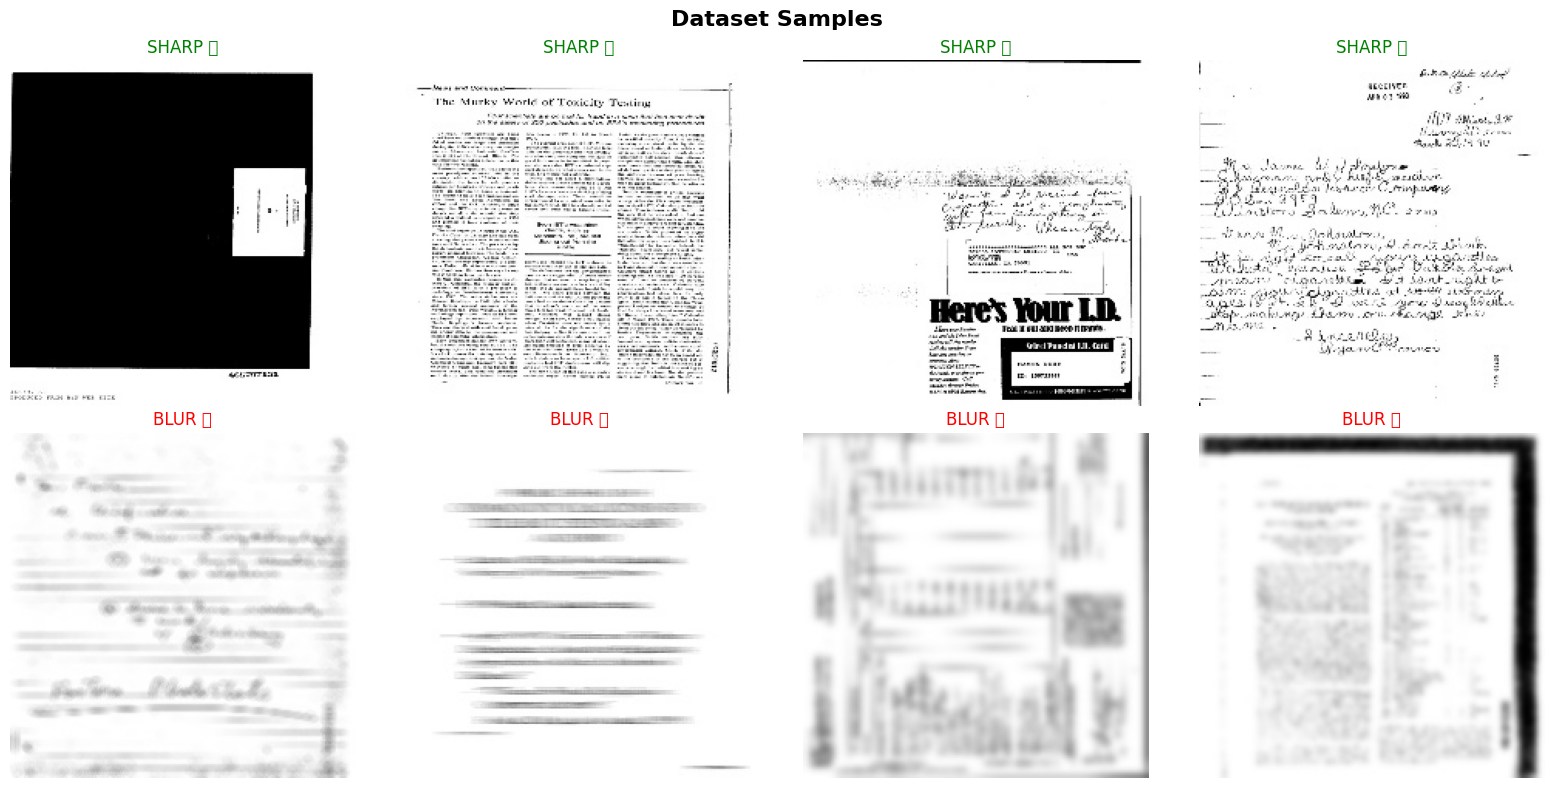

✅ Sample visualization saved!


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

sharp_imgs = random.sample(os.listdir(SHARP_DIR), 4)
blur_imgs  = random.sample(os.listdir(BLUR_DIR), 4)

for i in range(4):
    s = cv2.imread(os.path.join(SHARP_DIR, sharp_imgs[i]))
    axes[0, i].imshow(cv2.cvtColor(s, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title("SHARP ✅", color="green", fontsize=12)
    axes[0, i].axis("off")

    b = cv2.imread(os.path.join(BLUR_DIR, blur_imgs[i]))
    axes[1, i].imshow(cv2.cvtColor(b, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title("BLUR ❌", color="red", fontsize=12)
    axes[1, i].axis("off")

plt.suptitle("Dataset Samples", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("E:/document_forensics/results/dataset_samples.png")
plt.show()
print("✅ Sample visualization saved!")

In [8]:
import shutil, os

BASE_DIR = "E:/document_forensics/dataset"

folders_to_clean = [
    "sharp", "blur",
    "train/sharp", "train/blur",
    "val/sharp",   "val/blur",
    "test/sharp",  "test/blind"
]

for folder in folders_to_clean:
    path = os.path.join(BASE_DIR, folder)
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

print("✅ Old dataset cleared!")
print("🚀 Ready for 320,000 images!")

✅ Old dataset cleared!
🚀 Ready for 320,000 images!


In [9]:
import os, shutil, random
from tqdm import tqdm

RVL_CDIP_ROOT = "E:/RVL-CDIP"
IMAGE_ROOT    = os.path.join(RVL_CDIP_ROOT, "image_jpg")
SHARP_DIR     = "E:/document_forensics/dataset/sharp"

# Read ALL 3 label files (train + val + test)
all_entries = []
for label_file in ["train.txt", "val.txt", "test.txt"]:
    path = os.path.join(RVL_CDIP_ROOT, "labels", label_file)
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                all_entries.append(line.split()[0])

print(f"📋 Total images found : {len(all_entries)}")

# Copy ALL images
copied, failed = 0, 0

for rel_path in tqdm(all_entries, desc="Copying sharp images"):
    base = os.path.splitext(rel_path)[0]
    for ext in ['.jpg', '.jpeg', '.tif', '.tiff', '.png']:
        full_path = os.path.join(IMAGE_ROOT, base + ext)
        if os.path.exists(full_path):
            dest = os.path.join(SHARP_DIR, f"sharp_{copied:06d}{ext}")
            shutil.copy2(full_path, dest)
            copied += 1
            break
    else:
        failed += 1

print(f"\n✅ Copied  : {copied:,} sharp images")
print(f"⚠️  Failed  : {failed:,} not found")

📋 Total images found : 400000


Copying sharp images: 100%|██████████| 400000/400000 [07:25<00:00, 897.84it/s] 


✅ Copied  : 399,999 sharp images
⚠️  Failed  : 1 not found


In [10]:
import cv2, os, random
import numpy as np
from tqdm import tqdm

SHARP_DIR = "E:/document_forensics/dataset/sharp"
BLUR_DIR  = "E:/document_forensics/dataset/blur"

def gaussian_blur(img):
    k = random.choice([11, 15, 21, 25])
    return cv2.GaussianBlur(img, (k, k), 0)

def motion_blur(img):
    size = random.randint(10, 25)
    kernel = np.zeros((size, size))
    kernel[int((size-1)/2), :] = np.ones(size)
    kernel /= size
    return cv2.filter2D(img, -1, kernel)

def defocus_blur(img):
    r = random.randint(3, 8)
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
    kernel = kernel.astype(np.float32) / kernel.sum()
    return cv2.filter2D(img, -1, kernel)

def mild_blur(img):
    k = random.choice([3, 5, 7])
    return cv2.GaussianBlur(img, (k, k), 0)

BLUR_FNS = [gaussian_blur, motion_blur, defocus_blur, mild_blur]

images = os.listdir(SHARP_DIR)
print(f"🔄 Generating blur for {len(images):,} images...")
print(f"⏳ Estimated time: ~30-40 minutes")

for fname in tqdm(images, desc="Generating blur"):
    path = os.path.join(SHARP_DIR, fname)
    img  = cv2.imread(path)
    if img is None:
        continue

    img     = cv2.resize(img, (224, 224))
    blurred = random.choice(BLUR_FNS)(img.copy())

    cv2.imwrite(os.path.join(SHARP_DIR, fname), img)

    blur_name = fname.replace("sharp_", "blur_")
    cv2.imwrite(os.path.join(BLUR_DIR, blur_name), blurred)

print(f"\n✅ Sharp : {len(os.listdir(SHARP_DIR)):,}")
print(f"✅ Blur  : {len(os.listdir(BLUR_DIR)):,}")
print("🎉 Full dataset ready!")

🔄 Generating blur for 399,999 images...
⏳ Estimated time: ~30-40 minutes


Generating blur: 100%|██████████| 399999/399999 [51:27<00:00, 129.54it/s]



✅ Sharp : 399,999
✅ Blur  : 399,999
🎉 Full dataset ready!


In [11]:
import os, shutil, random
from tqdm import tqdm

BASE_DIR  = "E:/document_forensics/dataset"
SHARP_DIR = f"{BASE_DIR}/sharp"
BLUR_DIR  = f"{BASE_DIR}/blur"

sharp_imgs = os.listdir(SHARP_DIR)
blur_imgs  = os.listdir(BLUR_DIR)

random.shuffle(sharp_imgs)
random.shuffle(blur_imgs)

# 80% train, 10% val, 10% test
def split_list(lst):
    n = len(lst)
    return lst[:int(n*0.8)], lst[int(n*0.8):int(n*0.9)], lst[int(n*0.9):]

sharp_train, sharp_val, sharp_test = split_list(sharp_imgs)
blur_train,  blur_val,  blur_test  = split_list(blur_imgs)

def copy_files(files, src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    for f in tqdm(files, desc=f"→ {os.path.basename(dst_dir)}"):
        shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, f))

print("📦 Splitting dataset into train/val/test...")
copy_files(sharp_train, SHARP_DIR, f"{BASE_DIR}/train/sharp")
copy_files(sharp_val,   SHARP_DIR, f"{BASE_DIR}/val/sharp")
copy_files(sharp_test,  SHARP_DIR, f"{BASE_DIR}/test/sharp")
copy_files(blur_train,  BLUR_DIR,  f"{BASE_DIR}/train/blur")
copy_files(blur_val,    BLUR_DIR,  f"{BASE_DIR}/val/blur")
copy_files(blur_test,   BLUR_DIR,  f"{BASE_DIR}/test/blur")

print(f"\n✅ Split complete!")
print(f"   Train → Sharp: {len(sharp_train):,} | Blur: {len(blur_train):,} | Total: {len(sharp_train)+len(blur_train):,}")
print(f"   Val   → Sharp: {len(sharp_val):,}   | Blur: {len(blur_val):,}   | Total: {len(sharp_val)+len(blur_val):,}")
print(f"   Test  → Sharp: {len(sharp_test):,}  | Blur: {len(blur_test):,}  | Total: {len(sharp_test)+len(blur_test):,}")

📦 Splitting dataset into train/val/test...


→ blur: 100%|██████████| 40000/40000 [00:32<00:00, 1217.99it/s]


✅ Split complete!
   Train → Sharp: 319,999 | Blur: 319,999 | Total: 639,998
   Val   → Sharp: 40,000   | Blur: 40,000   | Total: 80,000
   Test  → Sharp: 40,000  | Blur: 40,000  | Total: 80,000


In [1]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os, random, torch

class BlurDataset(Dataset):
    def __init__(self, sharp_dir, blur_dir, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []

        for f in os.listdir(sharp_dir):
            self.images.append(os.path.join(sharp_dir, f))
            self.labels.append(0)  # 0 = Sharp

        for f in os.listdir(blur_dir):
            self.images.append(os.path.join(blur_dir, f))
            self.labels.append(1)  # 1 = Blur

        combined = list(zip(self.images, self.labels))
        random.shuffle(combined)
        self.images, self.labels = zip(*combined)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.images[idx]).convert("RGB")
        except:
            img = Image.new("RGB", (224, 224))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

BASE_DIR = "E:/document_forensics/dataset"

train_dataset = BlurDataset(f"{BASE_DIR}/train/sharp", f"{BASE_DIR}/train/blur", train_transform)
val_dataset   = BlurDataset(f"{BASE_DIR}/val/sharp",   f"{BASE_DIR}/val/blur",   val_transform)
test_dataset  = BlurDataset(f"{BASE_DIR}/test/sharp",  f"{BASE_DIR}/test/blur",  val_transform)

# ✅ FIXED — num_workers=0 for Windows
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ Train samples : {len(train_dataset):,}")
print(f"✅ Val samples   : {len(val_dataset):,}")
print(f"✅ Test samples  : {len(test_dataset):,}")
print(f"✅ Train batches : {len(train_loader):,}")
print(f"✅ Val batches   : {len(val_loader):,}")
print(f"✅ num_workers   : 0 (Windows fix)")
print(f"🚀 DataLoaders ready!")

✅ Train samples : 639,998
✅ Val samples   : 80,000
✅ Test samples  : 80,000
✅ Train batches : 10,000
✅ Val batches   : 1,250
✅ num_workers   : 0 (Windows fix)
🚀 DataLoaders ready!


In [4]:
import timm
import torch.nn as nn

class BlurDetector(nn.Module):
    def __init__(self):
        super(BlurDetector, self).__init__()
        self.model = timm.create_model(
            'efficientnet_b3',
            pretrained=True,
            num_classes=2
        )

    def forward(self, x):
        return self.model(x)

# Initialize
model = BlurDetector().to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model      : EfficientNetB3")
print(f"✅ Parameters : {total_params:,}")
print(f"✅ Device     : {device}")
print(f"✅ Optimizer  : AdamW")
print(f"✅ Scheduler  : CosineAnnealingLR")
print(f"🚀 Model ready for training!")

✅ Model      : EfficientNetB3
✅ Parameters : 10,699,306
✅ Device     : cuda
✅ Optimizer  : AdamW
✅ Scheduler  : CosineAnnealingLR
🚀 Model ready for training!


In [5]:
EPOCHS    = 15
BEST_ACC  = 0.0
MODEL_DIR = "E:/document_forensics/models"

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print("🚀 Starting Training on RTX 4070 Ti Super!")
print(f"📊 Train: 639,998 | Val: 80,000")
print(f"⏳ Estimated: ~4-5 hours for 15 epochs")
print("=" * 60)

for epoch in range(EPOCHS):
    # ── Training ──
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        _, predicted   = outputs.max(1)
        train_total   += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    # ── Validation ──
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  "):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)

            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_total   += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # ── Metrics ──
    t_loss = train_loss / len(train_loader)
    v_loss = val_loss   / len(val_loader)
    t_acc  = 100. * train_correct / train_total
    v_acc  = 100. * val_correct   / val_total

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    scheduler.step()

    # ── Save Best Model ──
    if v_acc > BEST_ACC:
        BEST_ACC = v_acc
        torch.save(model.state_dict(),
                   f"{MODEL_DIR}/best_blur_detector.pth")
        saved = "💾 Saved Best!"
    else:
        saved = ""

    print(f"\nEpoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc:.2f}% | "
          f"Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}% {saved}")
    print("-" * 60)

print(f"\n🏆 Best Validation Accuracy: {BEST_ACC:.2f}%")
print(f"💾 Model saved to: {MODEL_DIR}/best_blur_detector.pth")


🚀 Starting Training on RTX 4070 Ti Super!
📊 Train: 639,998 | Val: 80,000
⏳ Estimated: ~4-5 hours for 15 epochs


Epoch 1/15 [Val]  : 100%|██████████| 1250/1250 [03:01<00:00,  6.89it/s]



Epoch 01/15 | Train Loss: 0.0050 | Train Acc: 99.92% | Val Loss: 0.0006 | Val Acc: 99.98% 💾 Saved Best!
------------------------------------------------------------


Epoch 2/15 [Val]  : 100%|██████████| 1250/1250 [02:45<00:00,  7.56it/s]



Epoch 02/15 | Train Loss: 0.0018 | Train Acc: 99.97% | Val Loss: 0.0013 | Val Acc: 99.99% 💾 Saved Best!
------------------------------------------------------------


Epoch 3/15 [Train]:  13%|█▎        | 1266/10000 [07:45<53:33,  2.72it/s] 


KeyboardInterrupt: 

In [7]:
# Final evaluation on test set
model.load_state_dict(torch.load(f"{MODEL_DIR}/best_blur_detector.pth"))
model.eval()

test_correct = 0
test_total   = 0

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs      = model(imgs)
        _, predicted = outputs.max(1)
        test_total   += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = 100. * test_correct / test_total
print(f"\n{'='*40}")
print(f"🏆 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"✅ Total test images  : {test_total:,}")
print(f"✅ Correct predictions: {test_correct:,}")
print(f"✅ Wrong predictions  : {test_total - test_correct:,}")
print(f"{'='*40}")


Testing: 100%|██████████| 1250/1250 [03:11<00:00,  6.53it/s]


🏆 FINAL TEST ACCURACY: 99.98%
✅ Total test images  : 80,000
✅ Correct predictions: 79,986
✅ Wrong predictions  : 14


✅ Prediction function ready!
💡 Usage: predict_blur('path/to/document.jpg')


e:\document_forensics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


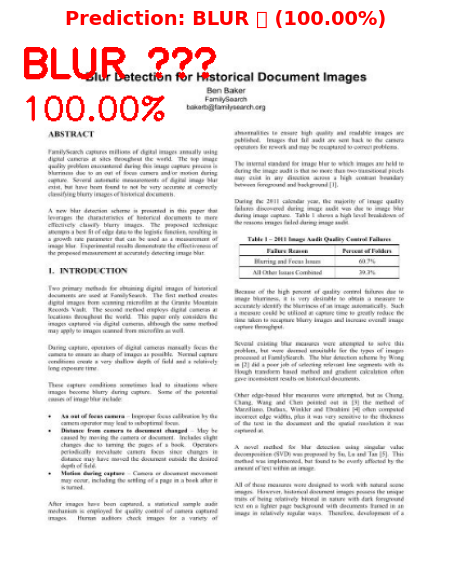

📄 Image      : C:/Users/Vaibhav/Downloads/blur-detection-for-historical-document-images.jpg.jpeg
🔍 Prediction : BLUR ❌
📊 Confidence : 100.00%


('BLUR ❌', 100.0)

In [12]:
from PIL import Image
import torch
from torchvision import transforms
import cv2
import numpy as np

# Load saved model
MODEL_PATH = "E:/document_forensics/models/best_blur_detector.pth"

model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Transform for prediction
predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_blur(image_path):
    # Load image
    img = Image.open(image_path).convert("RGB")
    
    # Transform
    tensor = predict_transform(img).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output     = model(tensor)
        probs      = torch.softmax(output, dim=1)
        confidence = probs.max().item() * 100
        pred       = output.argmax(dim=1).item()
    
    label  = "BLUR ❌" if pred == 1 else "SHARP ✅"
    
    # Show result
    img_cv = cv2.imread(image_path)
    img_cv = cv2.resize(img_cv, (400, 500))
    
    color = (0, 0, 255) if pred == 1 else (0, 255, 0)
    cv2.putText(img_cv, label,       (10, 40),  cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
    cv2.putText(img_cv, f"{confidence:.2f}%", (10, 80), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
    
    plt.figure(figsize=(6, 7))
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {label} ({confidence:.2f}%)",
              color="red" if pred == 1 else "green",
              fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()
    
    print(f"📄 Image      : {image_path}")
    print(f"🔍 Prediction : {label}")
    print(f"📊 Confidence : {confidence:.2f}%")
    
    return label, confidence

# ── Test it on any image ──
# predict_blur("path/to/your/document.jpg")
print("✅ Prediction function ready!")
print("💡 Usage: predict_blur('path/to/document.jpg')")

# ADD YOUR IMAGE PATH HERE ↓
predict_blur("C:/Users/Vaibhav/Downloads/blur-detection-for-historical-document-images.jpg.jpeg")